In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(scRepertoire)
library(circlize)
library(immunarch)
library(tidyr)
library(ggalluvial)
library(viridis)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))


Loading required package: dtplyr

Loading required package

In [2]:
so <- readRDS('vst2_t_cells.rds')

In [3]:
so$Day_Culture_pep_enriched <- paste(so$Day, so$Culture, so$pep_enriched, sep = '_')

# Heatmap

In [4]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.4.3”


In [5]:
curated_genes <- read.csv('curated_genes.csv')
head(curated_genes)

,Eff,AP,CS,RD
,<chr>,<chr>,<chr>,<chr>
1,IFNG,IFNG,IFNG,HAVCR2
2,CCL3,CCL5,CCL3,LAG3
3,KLRK1,KLRK1,CCL5,TIGIT
4,TIGIT,TIGIT,CSF2,IRF4
5,FCGR3A,FCGR3A,CCL4,PDCD1
6,PRF1,PRF1,CCR2,CTLA4


In [6]:
curated_long <- curated_genes %>% 
    pivot_longer(cols = everything(),
                 names_to = "pathway",
                 values_to = "gene") %>%
    filter(!is.na(gene) & gene != "")

In [7]:
curated_wide <- curated_long %>%
    group_by(gene) %>%
    summarise(pathway = paste(sort(unique(pathway)), collapse = ";"),
              .groups = 'drop')

In [8]:
so_subset <- so %>%
    subset(Day != 'Day_0') %>%
    subset(AIFI_PBMC.Flex_L2 %in% c('Memory CD8 T cell', 'Proliferating T cell'))

In [9]:
avg_exp <- AverageExpression(so_subset, group.by = 'Day_Culture_pep_enriched', features = curated_wide$gene)

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.
Warning message:
“The following 48 features were not found in the escape.ssGSEA assay: ADGRG5, BATF, CCL3, CCL4, CCL5, CCR2, CCR4, CCR5, CD70, CRTAM, CSF2, CTLA4, CTSW, CX3CR1, DUSP4, EGR2, ENTPD1, FABP5, FASLG, FCGR3A, GNLY, GZMB, GZMH, HAVCR2, HOPX, IFNG, IL2RA, IL5, IRF4, JUN, KLF2, KLRD1, KLRK1, LAG3, LMNA, MYB, PDCD1, PLEK, PRF1, RUNX2, TIGIT, TNFRSF9, TOX, VDR, YBX3, ZBED2, ZBTB32, ZEB2”
Warning message:
“None of the features specified were found in the escape.ssGSEA assay.”


In [10]:
avg_exp <- as.data.frame(avg_exp$RNA)

In [11]:
head(avg_exp)

,Day-10-IL4-IL7-Non-Activated,Day-10-IL4-IL7-Pep-Enriched,Day-10-IL7-IL15-Non-Activated,Day-10-IL7-IL15-Pep-Enriched,Day-4-IL4-IL7-Non-Activated,Day-4-IL4-IL7-Pep-Enriched,Day-4-IL7-IL15-Non-Activated,Day-4-IL7-IL15-Pep-Enriched,Day-7-IL4-IL7-Non-Activated,Day-7-IL4-IL7-Pep-Enriched,Day-7-IL7-IL15-Non-Activated,Day-7-IL7-IL15-Pep-Enriched
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TNFRSF9,0.19116757,0.9180285,0.1650755,0.6358304,0.4093757,5.50547847,0.6052815,3.8283224,0.28312310,2.0732754,0.2491644,1.367749
JUN,0.33290998,0.4085631,0.3731479,0.4436594,0.5342739,0.46326817,0.6524230,0.9228203,0.71924359,0.5353015,0.7042641,1.018620
LMNA,0.52249202,0.4295425,0.3106480,0.5436183,0.5993242,6.14552283,0.7439705,4.8895485,1.53057224,2.2312934,1.2692623,2.408000
FCGR3A,0.04230178,0.4485333,0.2376329,2.6969679,0.2476640,0.07592125,0.3972586,0.5645145,0.06377342,0.1081014,0.2784349,1.303713
FASLG,0.35992557,2.0771590,0.7906067,1.6966127,0.3563681,1.36110101,0.4975023,1.4748327,0.36166334,1.4076016,0.6484841,1.033688
PLEK,0.38838258,2.0752208,0.6562001,2.6869985,1.1836783,0.80499512,0.8010146,1.2521273,0.38297940,1.0690115,0.5589863,1.544565


In [12]:
anno_col <- data.frame(row.names = colnames(avg_exp))
splits <- strsplit(rownames(anno_col), '-')
anno_col$Day <- sapply(splits, function(x) paste(x[1],x[2]))
anno_col$Culture <- sapply(splits, function(x) paste(x[3],x[4]))
anno_col$Activation <- sapply(splits, function(x) paste(x[5],x[6]))                          
anno_col

,Day,Culture,Activation
,<chr>,<chr>,<chr>
Day-10-IL4-IL7-Non-Activated,Day 10,IL4 IL7,Non Activated
Day-10-IL4-IL7-Pep-Enriched,Day 10,IL4 IL7,Pep Enriched
Day-10-IL7-IL15-Non-Activated,Day 10,IL7 IL15,Non Activated
Day-10-IL7-IL15-Pep-Enriched,Day 10,IL7 IL15,Pep Enriched
Day-4-IL4-IL7-Non-Activated,Day 4,IL4 IL7,Non Activated
Day-4-IL4-IL7-Pep-Enriched,Day 4,IL4 IL7,Pep Enriched
Day-4-IL7-IL15-Non-Activated,Day 4,IL7 IL15,Non Activated
Day-4-IL7-IL15-Pep-Enriched,Day 4,IL7 IL15,Pep Enriched
Day-7-IL4-IL7-Non-Activated,Day 7,IL4 IL7,Non Activated


In [13]:
anno_row <- data.frame(row.names = curated_wide$gene, 
                       Pathway = curated_wide$pathway)

In [14]:
avg_exp <- avg_exp[,c('Day-4-IL4-IL7-Non-Activated','Day-4-IL7-IL15-Non-Activated','Day-7-IL4-IL7-Non-Activated','Day-7-IL7-IL15-Non-Activated','Day-10-IL4-IL7-Non-Activated','Day-10-IL7-IL15-Non-Activated',
                      'Day-4-IL4-IL7-Pep-Enriched','Day-4-IL7-IL15-Pep-Enriched','Day-7-IL4-IL7-Pep-Enriched','Day-7-IL7-IL15-Pep-Enriched','Day-10-IL4-IL7-Pep-Enriched','Day-10-IL7-IL15-Pep-Enriched')]

In [15]:
library(pheatmap)

In [16]:
ann_colors = list(
    Activation = c(`Non Activated` = '#175676', `Pep Enriched` = '#d62839'),
    Culture = c(`IL4 IL7` = "#ff9505", `IL7 IL15` = "#b8b8ff"),
    Day = c(`Day 4` = "#95d5b2", `Day 7` = "#52b788", `Day 10` = "#2d6a4f")
)

In [17]:
my_colors <- colorRampPalette(c("navy", "white", "red"))(50)

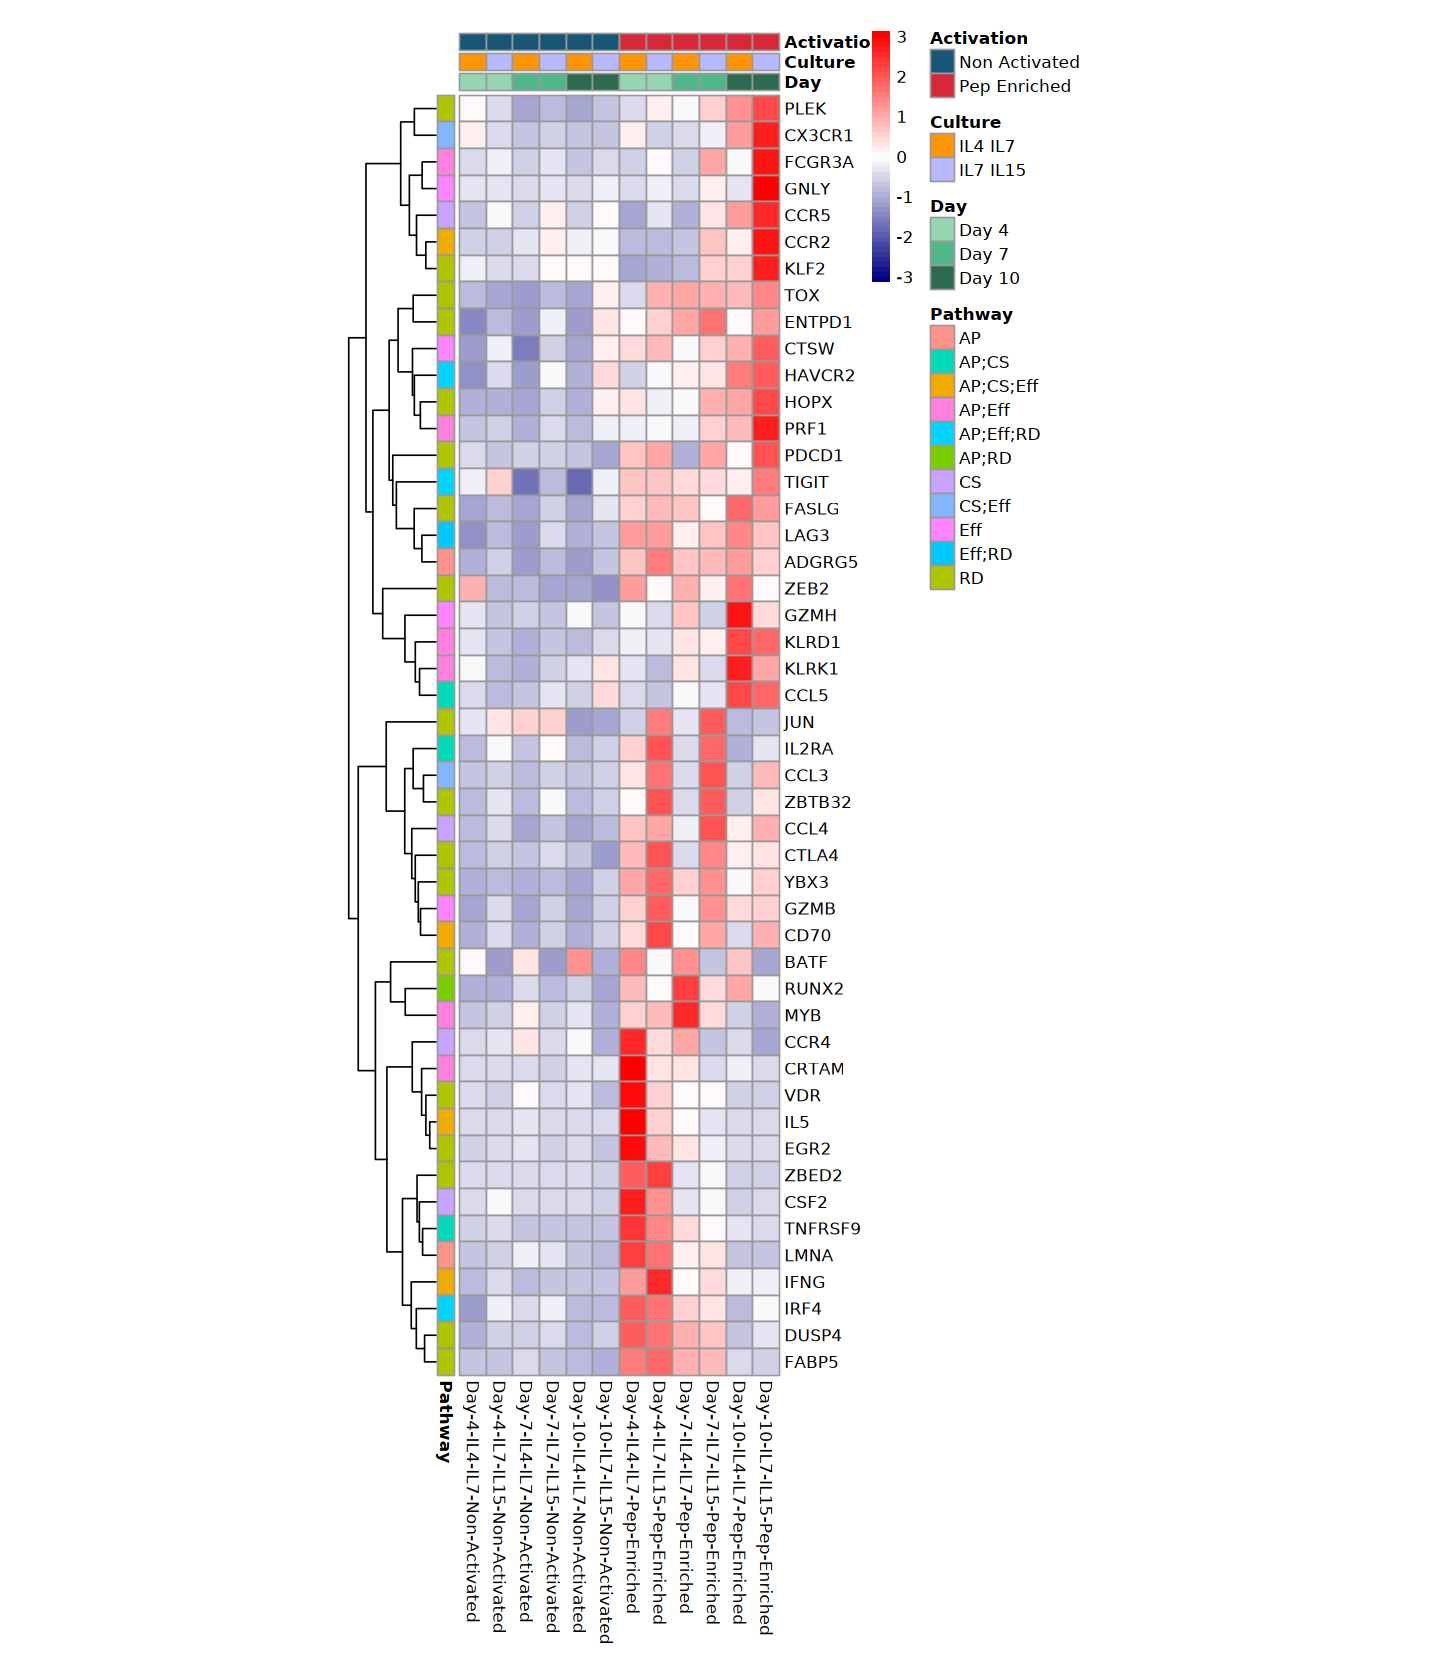

In [18]:
options(repr.plot.width = 12, repr.plot.height = 14)
p_heatmap <- pheatmap(avg_exp, scale = 'row', cluster_cols = F, cluster_rows = T, annotation_col = anno_col, annotation_row = anno_row, color = my_colors, annotation_colors = ann_colors, cellwidth = 16, cellheight = 16)

In [19]:
# Open the PDF graphics device
pdf("plots/Fig2c_DEG_Heatmap.pdf", width = 12, height = 14) # You can specify width and height in inches

# Create your plot
print(p_heatmap)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

# IL4 vs IL15

In [37]:
so@meta.data %>%
    filter(`RNA_snn_res.0.8` %in% c(4,15,20,22,28,31)) %>%
    group_by(`RNA_snn_res.0.8`, Culture) %>%
    summarise(count = n()) %>%
    group_by(`RNA_snn_res.0.8`) %>%
    mutate(perc = count / sum(count)*100) %>%
    filter(Culture == 'IL4_IL7')

`summarise()` has grouped output by 'RNA_snn_res.0.8'. You can override using
the `.groups` argument.


RNA_snn_res.0.8,Culture,count,perc
<fct>,<chr>,<int>,<dbl>
15,IL4_IL7,235,1.2115276
20,IL4_IL7,14537,96.3289378
22,IL4_IL7,630,4.9057779
28,IL4_IL7,6068,95.4988983
31,IL4_IL7,107,5.3286853
4,IL4_IL7,268,0.9441606


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



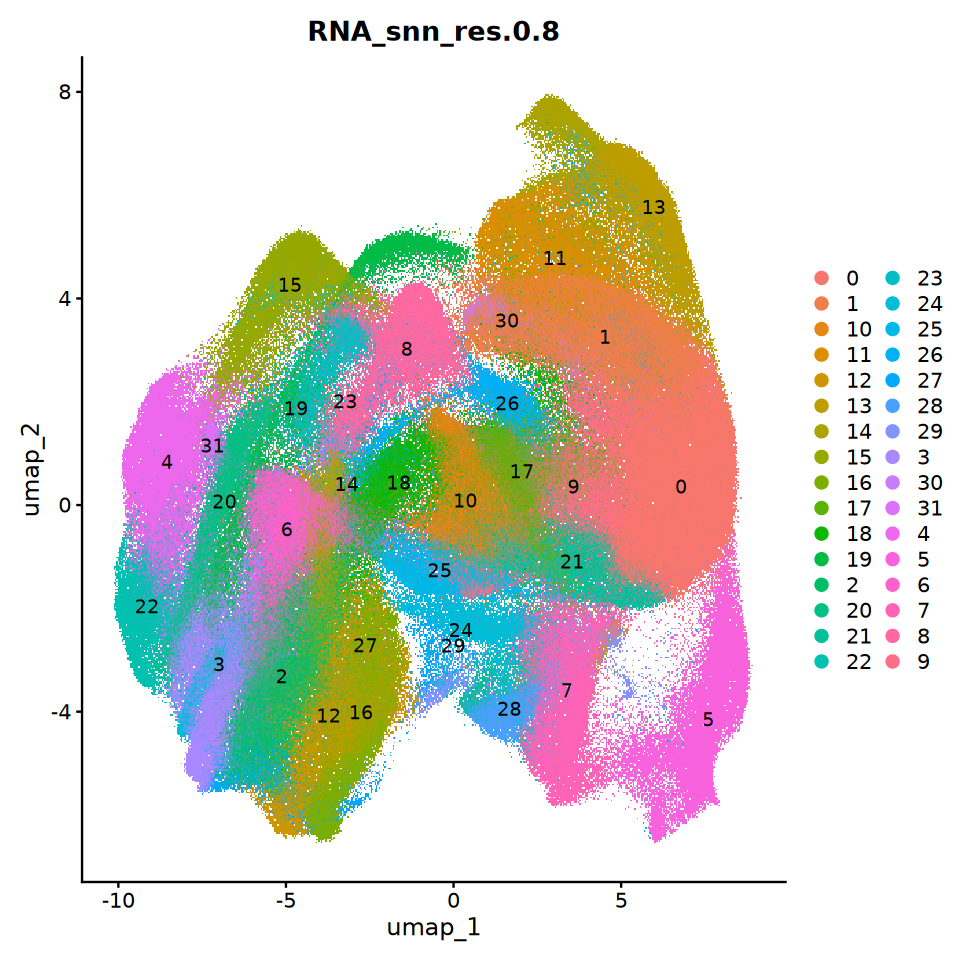

In [35]:
options(repr.plot.width = 8, repr.plot.height = 8)
DimPlot(so, group.by = 'RNA_snn_res.0.8', label = T)

In [48]:
c28 <- FindMarkers(so, ident.1 = 28, group.by = 'RNA_snn_res.0.8')

In [50]:
head(c28, n=15)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GZMH,0,3.208241,0.730,0.186,0
SOCS1,0,-2.343041,0.231,0.764,0
SPOCK2,0,-3.321664,0.066,0.594,0
KLRD1,0,2.442599,0.770,0.279,0
CCL4,0,1.723135,0.746,0.259,0
RCAN3,0,-2.664599,0.095,0.561,0
LTB,0,-2.374027,0.407,0.855,0
GZMB,0,1.538113,0.809,0.362,0
LAG3,0,2.015188,0.853,0.411,0


In [49]:
head(subset(c28, avg_log2FC > 0), n=15)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GZMH,0,3.208241,0.730,0.186,0
KLRD1,0,2.442599,0.770,0.279,0
CCL4,0,1.723135,0.746,0.259,0
GZMB,0,1.538113,0.809,0.362,0
LAG3,0,2.015188,0.853,0.411,0
AOAH,0,2.600882,0.712,0.276,0
EOMES,0,2.527380,0.711,0.289,0
KLRK1,0,2.069828,0.933,0.515,0
CCL5,0,2.632151,0.999,0.583,0


In [38]:
pep_rich <- subset(so, pep_enriched == 'Pep-Enriched')
pep_rich

An object of class Seurat 
18168 features across 84077 samples within 2 assays 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: escape.ssGSEA
 2 dimensional reductions calculated: pca, umap

In [41]:
pep_rich$Day_Culture <- paste(pep_rich$Day, pep_rich$Culture, sep = '_')

In [44]:
table(pep_rich$Day_Culture)


       Day_0_NA  Day_10_IL4_IL7 Day_10_IL7_IL15   Day_4_IL4_IL7  Day_4_IL7_IL15 
              6           12720           29376            1028            2849 
  Day_7_IL4_IL7  Day_7_IL7_IL15 
           8097           30001 

In [45]:
il4_v_il15 <- FindMarkers(pep_rich, ident.1 = 'Day_10_IL4_IL7', ident.2 = 'Day_10_IL7_IL15', group.by = 'Day_Culture')

In [46]:
head(il4_v_il15, n = 15)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IL12RB2,0,-4.756533,0.040,0.662,0
GNLY,0,-3.937373,0.222,0.844,0
STX3,0,-2.849053,0.192,0.810,0
TGFBR1,0,-2.451807,0.226,0.781,0
PXN,0,-2.232651,0.213,0.733,0
LTB,0,-2.675551,0.448,0.959,0
IFI44L,0,-2.143177,0.149,0.647,0
CCL3,0,-3.013324,0.173,0.664,0
FCGR3A,0,-2.591574,0.102,0.577,0


In [47]:
head(subset(il4_v_il15, avg_log2FC > 0), n = 15)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HOMER2,0,5.247846,0.505,0.038,0
ITGAX,0,3.208618,0.427,0.085,0
EOMES,0,2.071224,0.796,0.515,0
GZMH,0,1.362242,0.790,0.556,0
BCL2L11,0,2.618882,0.342,0.111,0
RNF125,0,1.959186,0.812,0.590,0
KRAS,0,1.768584,0.824,0.605,0
GZMK,0,1.008389,0.759,0.548,0
SLC26A11,0,1.907476,0.354,0.154,0


In [6]:
so$Culture_pep_enriched <- paste(so$Culture, so$pep_enriched, sep = '-')

In [7]:
so_subset <- subset(so, Day != 'Day_0' & AIFI_PBMC.Flex_L2 %in% c('Memory CD8 T cell','Proliferating T cell'))

Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


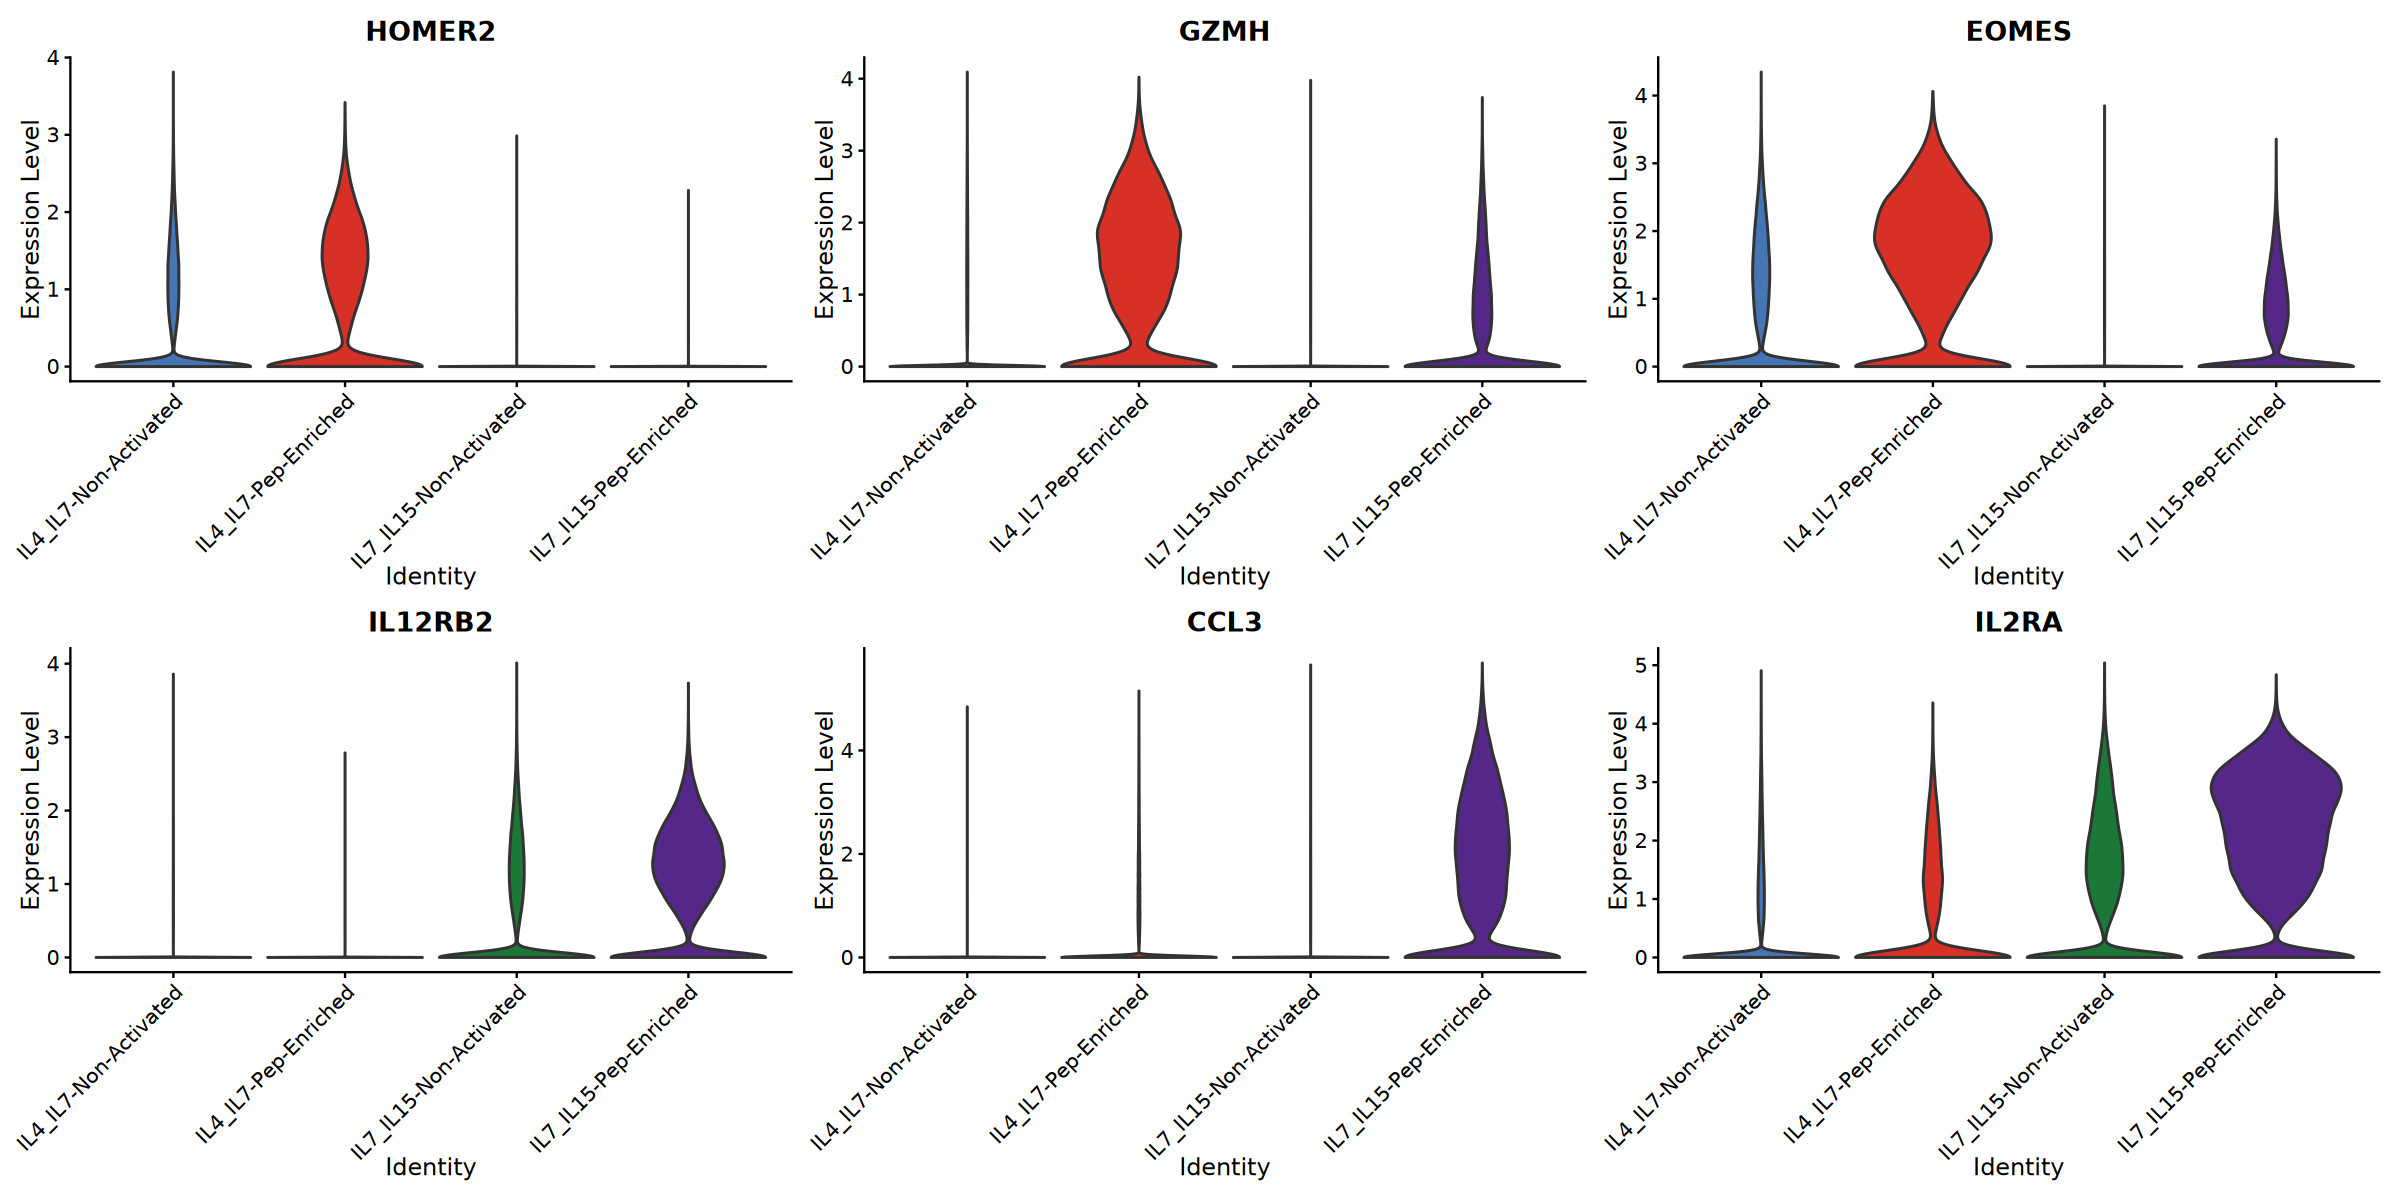

In [10]:
options(repr.plot.width = 20, repr.plot.height = 10)
VlnPlot(so_subset, features = c('HOMER2','GZMH','EOMES',
                                'IL12RB2','CCL3','IL2RA'), ncol=3, 
        group.by = 'Culture_pep_enriched', pt.size = 0,
        cols = c('#4575b4','#d73027','#1b7837','#542788'), raster = F)

In [11]:
# Open the PDF graphics device
pdf("plots/Fig2c_Violin_plots_IL4_IL15_markers.pdf", width = 20, height = 10) # You can specify width and height in inches

# Create your plot
VlnPlot(so_subset, features = c('HOMER2','GZMH','EOMES',
                                'IL12RB2','CCL3','IL2RA'), ncol=3, 
        group.by = 'Culture_pep_enriched', pt.size = 0,
        cols = c('#4575b4','#d73027','#1b7837','#542788'), raster = F)

# Close the graphics device to save the plot
dev.off()

Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


pdf 
  2

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set

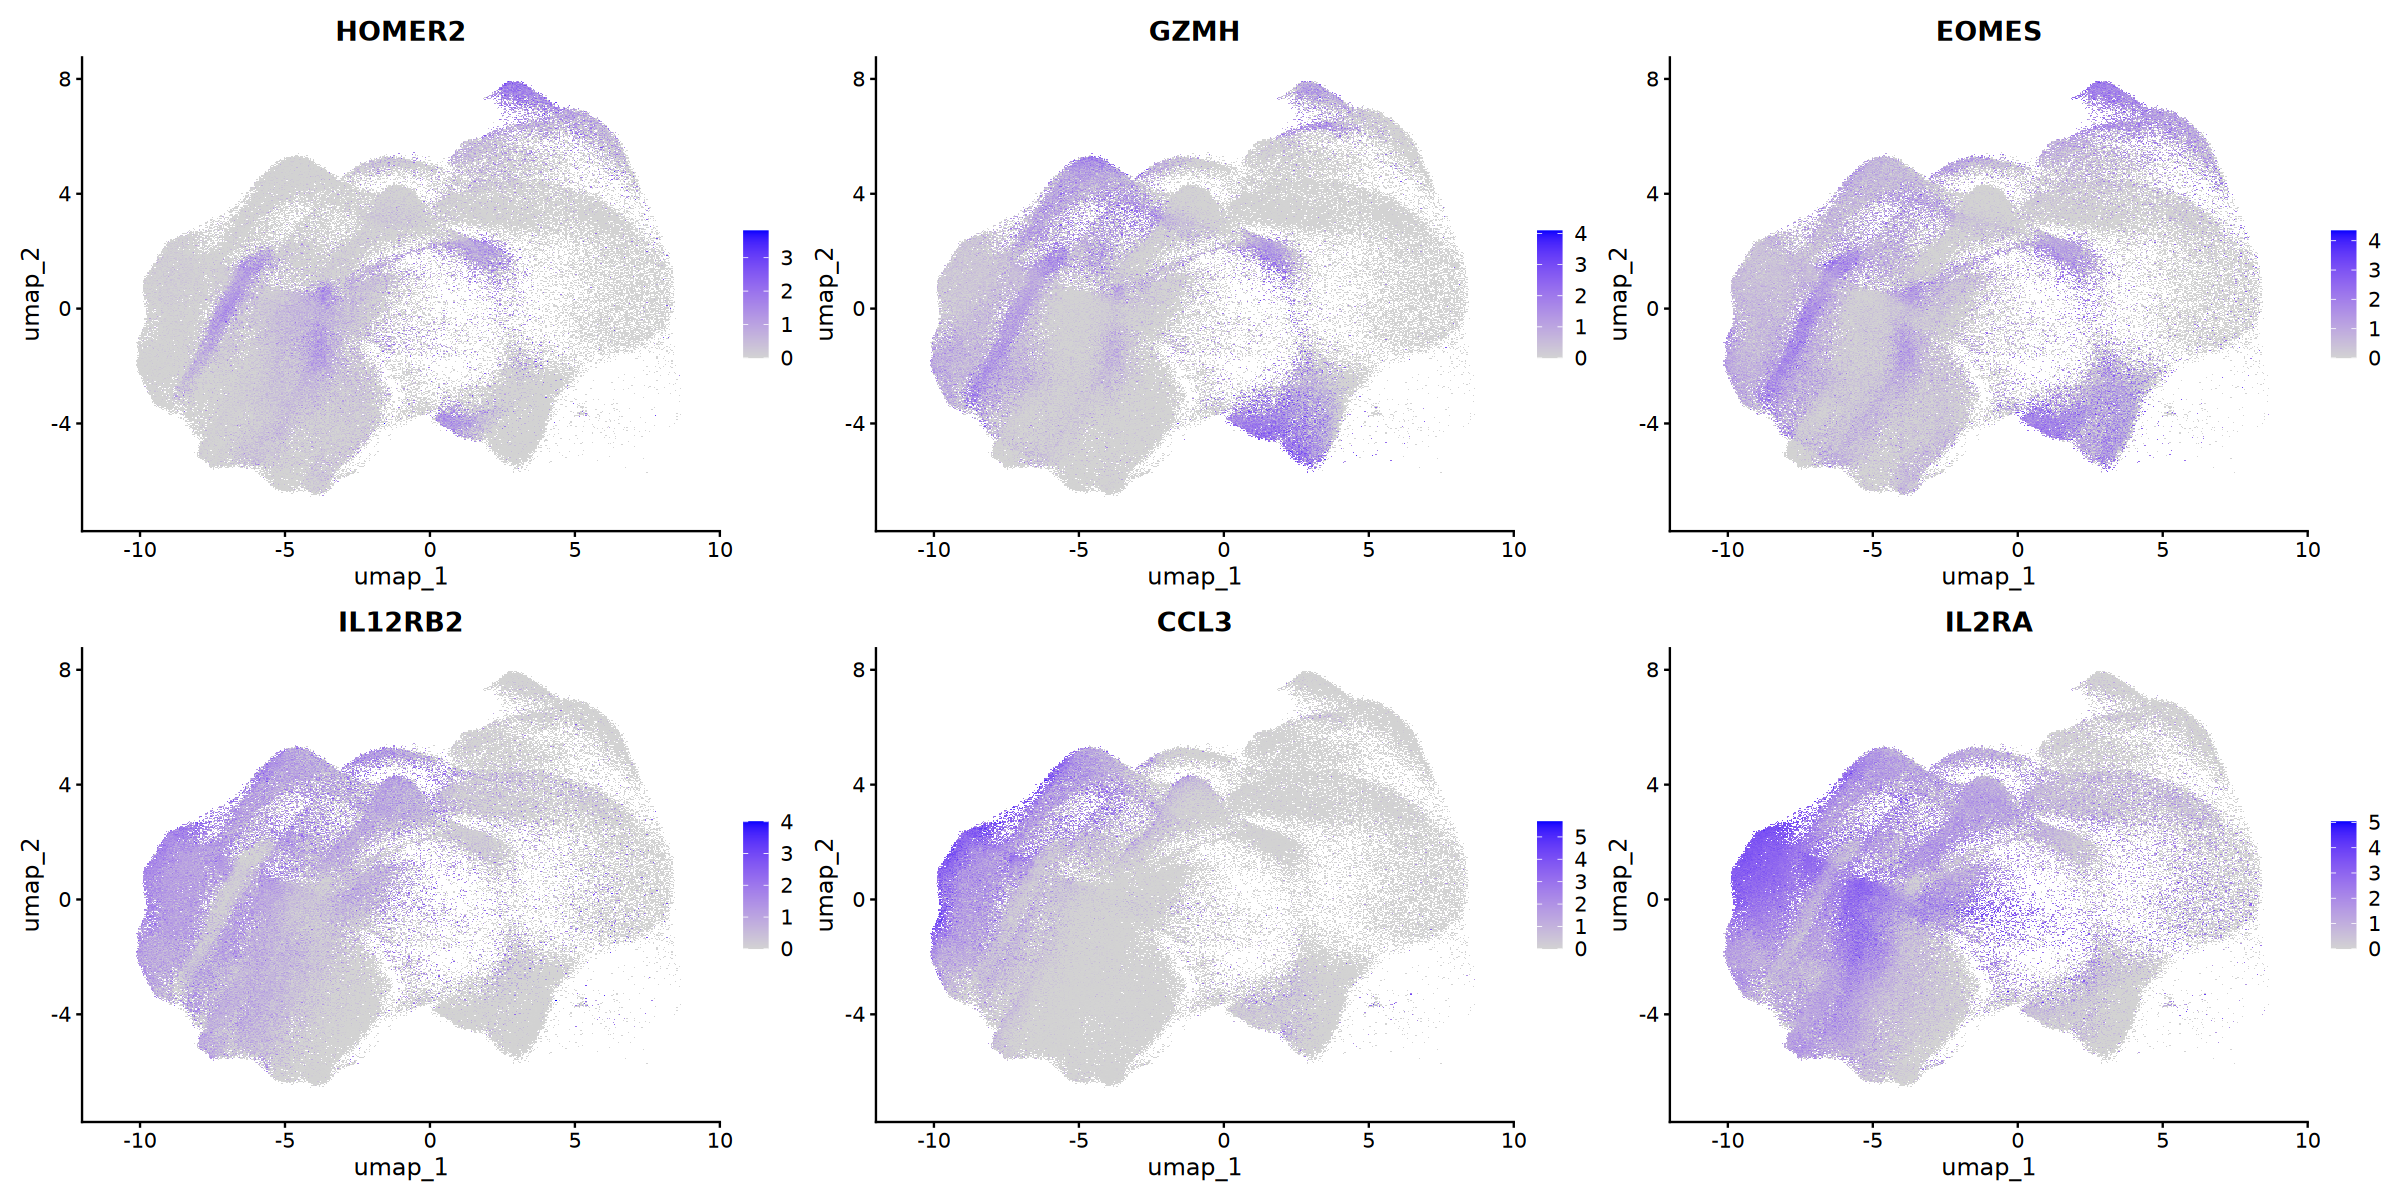

In [6]:
options(repr.plot.width = 20, repr.plot.height = 10)
FeaturePlot(so_subset, features = c('HOMER2','GZMH','EOMES',
                                'IL12RB2','CCL3','IL2RA'), ncol=3)

# Pathway Analysis

In [12]:
options(repr.plot.width = 6, repr.plot.height = 6)
d4_il4_ridge <- so %>%
    subset(Day == 'Day_4') %>%
    subset(Culture == 'IL4_IL7') %>%
    subset(cloneSize %in% c('Medium (0.001 < X <= 0.01)','Large (0.01 < X <= 0.1)')) %>%
    RidgePlot(group.by = 'pep_enriched', features = 'REACTOME-HCMV-INFECTION',
              cols = c('#4575b4','#d73027')) + xlim(-200,5000) + NoLegend()
d4_il15_ridge <- so %>%
    subset(Day == 'Day_4') %>%
    subset(Culture == 'IL7_IL15') %>%
    subset(cloneSize %in% c('Medium (0.001 < X <= 0.01)','Large (0.01 < X <= 0.1)')) %>%
    RidgePlot(group.by = 'pep_enriched', features = 'REACTOME-HCMV-INFECTION',
              cols = c('#1b7837','#542788')) + xlim(-200,5000) + NoLegend()

Warning message:
“Removing 18215 cells missing data for vars requested”
Warning message:
“Could not find REACTOME-HCMV-INFECTION in the default search locations, found in ‘escape.ssGSEA’ assay instead”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removing 8662 cells missing data for vars requested”
Warning message:
“Could not find REACTOME-HCMV-INFECTION in the default search locations, found in ‘escape.ssGSEA’ assay instead”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


In [13]:
d7_il4_ridge <- so %>%
    subset(Day == 'Day_7') %>%
    subset(Culture == 'IL4_IL7') %>%
    subset(cloneSize %in% c('Medium (0.001 < X <= 0.01)','Large (0.01 < X <= 0.1)')) %>%
    RidgePlot(group.by = 'pep_enriched', features = 'REACTOME-HCMV-INFECTION',
              cols = c('#4575b4','#d73027')) + xlim(-200,5000) + NoLegend()
d7_il15_ridge <- so %>%
    subset(Day == 'Day_7') %>%
    subset(Culture == 'IL7_IL15') %>%
    subset(cloneSize %in% c('Medium (0.001 < X <= 0.01)','Large (0.01 < X <= 0.1)')) %>%
    RidgePlot(group.by = 'pep_enriched', features = 'REACTOME-HCMV-INFECTION',
              cols = c('#1b7837','#542788')) + xlim(-200,5000) + NoLegend()

Warning message:
“Removing 13335 cells missing data for vars requested”
Warning message:
“Could not find REACTOME-HCMV-INFECTION in the default search locations, found in ‘escape.ssGSEA’ assay instead”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removing 15310 cells missing data for vars requested”
Warning message:
“Could not find REACTOME-HCMV-INFECTION in the default search locations, found in ‘escape.ssGSEA’ assay instead”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


In [14]:
d10_il4_ridge <- so %>%
    subset(Day == 'Day_10') %>%
    subset(Culture == 'IL4_IL7') %>%
    subset(cloneSize %in% c('Medium (0.001 < X <= 0.01)','Large (0.01 < X <= 0.1)')) %>%
    RidgePlot(group.by = 'pep_enriched', features = 'REACTOME-HCMV-INFECTION',
              cols = c('#4575b4','#d73027')) + xlim(-200,5000) + NoLegend()
d10_il15_ridge <- so %>%
    subset(Day == 'Day_10') %>%
    subset(Culture == 'IL7_IL15') %>%
    subset(cloneSize %in% c('Medium (0.001 < X <= 0.01)','Large (0.01 < X <= 0.1)')) %>%
    RidgePlot(group.by = 'pep_enriched', features = 'REACTOME-HCMV-INFECTION',
              cols = c('#1b7837','#542788')) + xlim(-200,5000) + NoLegend()

Warning message:
“Removing 12108 cells missing data for vars requested”
Warning message:
“Could not find REACTOME-HCMV-INFECTION in the default search locations, found in ‘escape.ssGSEA’ assay instead”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removing 12384 cells missing data for vars requested”
Warning message:
“Could not find REACTOME-HCMV-INFECTION in the default search locations, found in ‘escape.ssGSEA’ assay instead”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


Picking joint bandwidth of 225

Picking joint bandwidth of 181

Picking joint bandwidth of 144

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_density_ridges()`).”
Picking joint bandwidth of 176

Picking joint bandwidth of 124

Picking joint bandwidth of 126



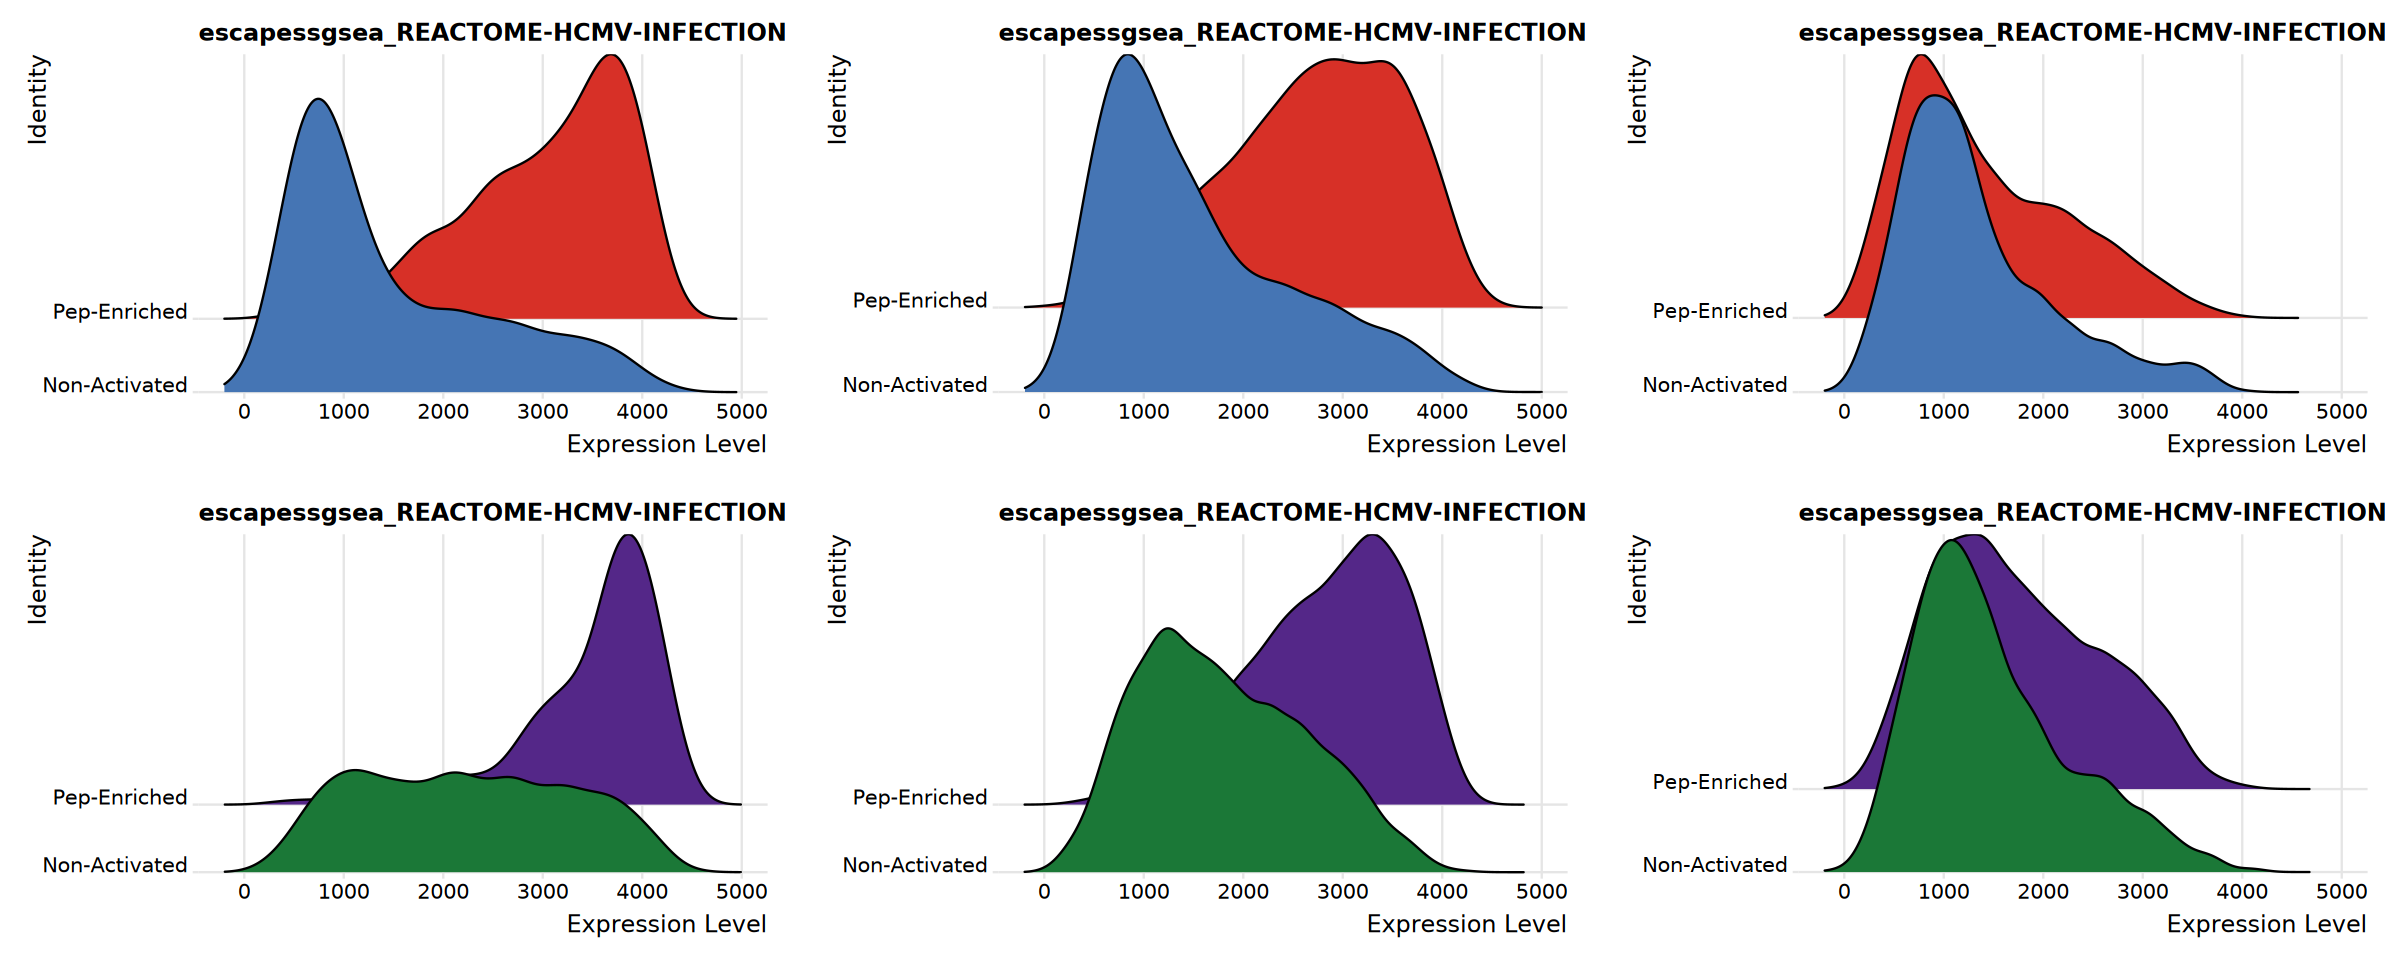

In [15]:
options(repr.plot.width = 20, repr.plot.height = 8)
cowplot::plot_grid(d4_il4_ridge,d7_il4_ridge,d10_il4_ridge,
                   d4_il15_ridge,d7_il15_ridge,d10_il15_ridge, ncol=3)

In [16]:
# Open the PDF graphics device
pdf("plots/Fig2c_CMV_Pathway_Ridgeplot.pdf", width = 20, height = 8) # You can specify width and height in inches

# Create your plot
cowplot::plot_grid(d4_il4_ridge,d7_il4_ridge,d10_il4_ridge,
                   d4_il15_ridge,d7_il15_ridge,d10_il15_ridge, ncol=3)

# Close the graphics device to save the plot
dev.off()

Picking joint bandwidth of 225

Picking joint bandwidth of 181

Picking joint bandwidth of 144

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_density_ridges()`).”
Picking joint bandwidth of 176

Picking joint bandwidth of 124

Picking joint bandwidth of 126



pdf 
  2

In [152]:
saveRDS(so, 'vst2_clustered_for_activation.rds')

In [2]:
so <- readRDS('vst2_clustered_for_activation.rds')